# Patient-Level Data Analysis

This notebook summarizes exploratory analysis of the static patient table (`patients.csv`) used in the MedHack: Frontiers 2026 Small Track (Coding) winning solution. It focuses on the schema, missingness patterns, categorical cardinalities, and medication terminology to inform feature engineering for the final risk-state classifier.

## 1. Dynamic time-series features (`train_data.csv`)

We first examine the dynamic vital-sign features in `train_data.csv` at the timestamp level. The goal is to understand:

- How frequently each vital sign is missing.
- What fraction of timestamps have at least one missing dynamic feature.

This informs whether we should rely on **imputation strategies** (e.g., interpolation, forward/backward fill) and/or **explicit masking** of missing values in the sequence model.

In [1]:
import pandas as pd

# Load dynamic time-series data
train_df = pd.read_csv("../data/train_data.csv", parse_dates=["timestamp"])  # columns: timestamp, encounter_id, vitals..., label

print("Columns in train_data.csv:\n", train_df.columns.tolist())
print("\nNumber of rows:", len(train_df))
print("Number of unique encounters (patients):", train_df["encounter_id"].nunique())

# Identify dynamic vital-sign columns (exclude timestamp, id, and label)
non_feature_cols = {"timestamp", "encounter_id", "label"}
dynamic_cols = [c for c in train_df.columns if c not in non_feature_cols]
print("\nDynamic feature columns:", dynamic_cols)

Columns in train_data.csv:
 ['timestamp', 'encounter_id', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'respiratory_rate', 'oxygen_saturation', 'label']

Number of rows: 2109600
Number of unique encounters (patients): 2930

Dynamic feature columns: ['heart_rate', 'systolic_bp', 'diastolic_bp', 'respiratory_rate', 'oxygen_saturation']


Encounter b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0 – 720 timestamps, 5 vitals


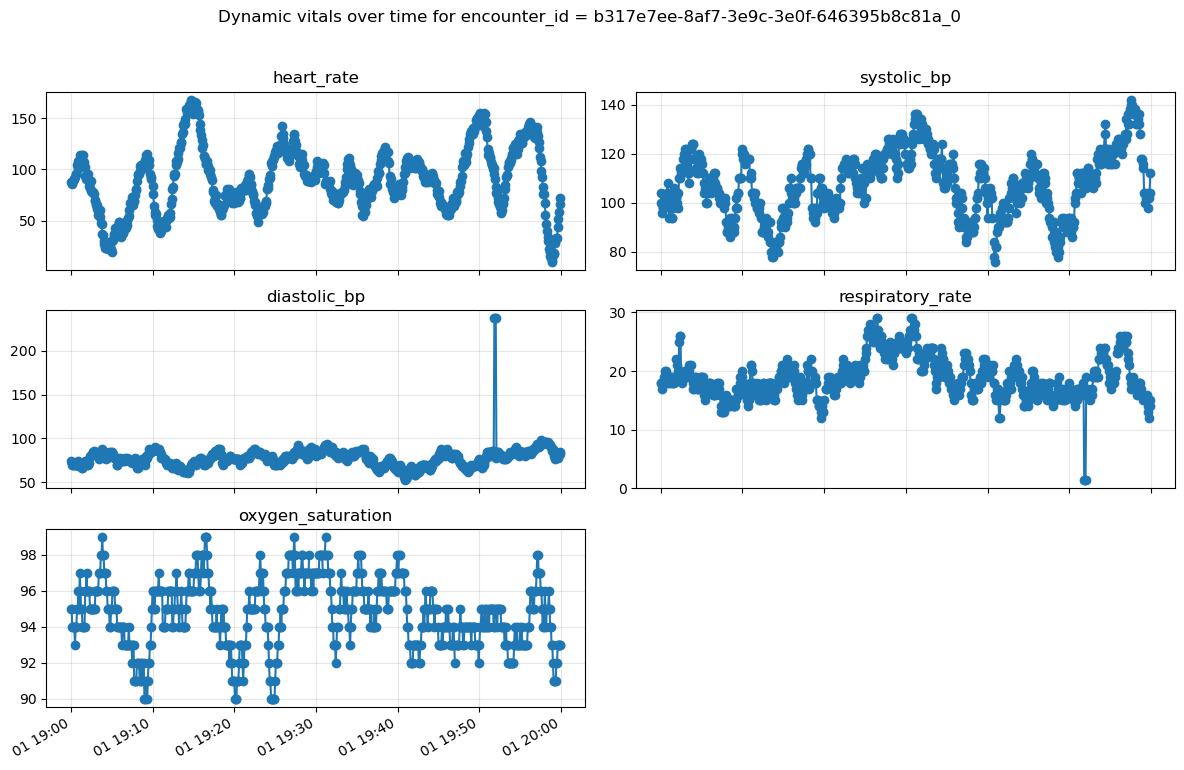

In [2]:
# Visualize vitals over time for a single encounter_id

import matplotlib.pyplot as plt
import numpy as np

# Choose encounter_id to inspect
encounter_to_plot = "b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0"  # <-- replace with any valid ID

# Filter and sort by time
enc_df = train_df[train_df["encounter_id"] == encounter_to_plot].copy()
if enc_df.empty:
    print(f"No rows found for encounter_id={encounter_to_plot!r}")
else:
    enc_df = enc_df.sort_values("timestamp")

    # Dynamic vitals only (reuse the same definition you used earlier)
    non_feature_cols = {"timestamp", "encounter_id", "label"}
    vitals_cols = [c for c in enc_df.columns if c not in non_feature_cols]

    print(f"Encounter {encounter_to_plot} – {len(enc_df)} timestamps, {len(vitals_cols)} vitals")

    # Plot each vital as its own subplot over time
    n_vitals = len(vitals_cols)
    n_cols = 2
    n_rows = int(np.ceil(n_vitals / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 2.5 * n_rows),
        sharex=True
    )

    # Flatten axes for easy indexing
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, vitals_cols):
        ax.plot(enc_df["timestamp"], enc_df[col], marker="o", linestyle="-")
        ax.set_title(col)
        ax.grid(True, alpha=0.3)

    # Hide any unused subplots
    for ax in axes[len(vitals_cols):]:
        ax.set_visible(False)

    fig.suptitle(f"Dynamic vitals over time for encounter_id = {encounter_to_plot}", y=1.02)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [3]:
# Per-feature missingness for dynamic vitals

missing_per_col = train_df[dynamic_cols].isna().mean().sort_values(ascending=False)
print("Fraction of missing values per dynamic feature:\n")
print((missing_per_col * 100).round(2).astype(str) + "%")

# Fraction of timestamps with at least one missing dynamic feature
row_has_missing = train_df[dynamic_cols].isna().any(axis=1)
frac_rows_with_missing = row_has_missing.mean() * 100

print(f"\nPercentage of timestamps with at least one missing dynamic feature: {frac_rows_with_missing:.2f}%")

Fraction of missing values per dynamic feature:

oxygen_saturation    2.02%
diastolic_bp         2.01%
respiratory_rate      2.0%
heart_rate            2.0%
systolic_bp           2.0%
dtype: object

Percentage of timestamps with at least one missing dynamic feature: 9.61%


The above statistics show that a non-trivial fraction of timestamps have missing vital-sign measurements.

For the final pipeline, this motivates:

- Incorporating **time-series imputation** (e.g., interpolation plus forward/backward fill) to provide dense inputs to the model.
- Optionally adding **explicit missingness masks** so that the sequence model can distinguish imputed values from truly observed values.

In [4]:
import pandas as pd

# Load static patient-level table
patients = pd.read_csv("../data/patients.csv")

print(patients.columns)

# Check for missing values in each column
missing = patients.isna().sum()
if missing.any():
    print("\nMissing values per column:")
    print(missing[missing > 0])
else:
    print("\nNo missing values in any column.")

Index(['encounter_id', 'patient_name', 'age', 'date_of_birth', 'gender',
       'race', 'ethnicity', 'marital_status', 'encounter_class',
       'encounter_description', 'reason_for_visit', 'previous_medical_history',
       'current_medications', 'previous_medications', 'known_allergies', 'bmi',
       'pain_score'],
      dtype='object')

Missing values per column:
marital_status              1164
reason_for_visit             548
previous_medical_history    1069
current_medications         2449
previous_medications        2782
known_allergies             3563
bmi                         2728
pain_score                  2675
dtype: int64


## 2. Static patient features (`patients.csv`)

The competition splits encounters into **train**, **test**, and **holdout** sets, but all of these draw from the same underlying pool of patients described in `patients.csv`. Each split simply uses a subset of the encounters/patients, and together they form a partition of the full cohort.

This means we can safely analyze the static patient table **without conditioning on a particular split or encounter_id linkage**—the high-level distributions and missingness patterns in `patients.csv` apply consistently across train, test, and holdout.

In this section, we focus on:

- The number of patients and missingness profile per column.
- Which features are categorical and how many categories they have.
- Pairwise **mutual information between explanatory (non-text) static variables**, to understand redundancy and shared signal.

These insights drive how we encode static inputs and how they complement the dynamic vitals.

In [5]:
# Cardinality and non-null counts per feature (excluding ID-like columns)
exclude_cols = {"encounter_id", "patient_name", "date_of_birth"}

for col in patients.columns:
    if col in exclude_cols:
        continue
    num_categories = patients[col].nunique(dropna=True)
    num_non_null = patients[col].notna().sum()
    print(f"{col}: {num_categories} categories, {num_non_null} non-NaN patients")

age: 110 categories, 4186 non-NaN patients
gender: 2 categories, 4186 non-NaN patients
race: 6 categories, 4186 non-NaN patients
ethnicity: 2 categories, 4186 non-NaN patients
marital_status: 4 categories, 3022 non-NaN patients
encounter_class: 1 categories, 4186 non-NaN patients
encounter_description: 9 categories, 4186 non-NaN patients
reason_for_visit: 31 categories, 3638 non-NaN patients
previous_medical_history: 2732 categories, 3117 non-NaN patients
current_medications: 839 categories, 1737 non-NaN patients
previous_medications: 1029 categories, 1404 non-NaN patients
known_allergies: 369 categories, 623 non-NaN patients
bmi: 214 categories, 1458 non-NaN patients
pain_score: 9 categories, 1511 non-NaN patients


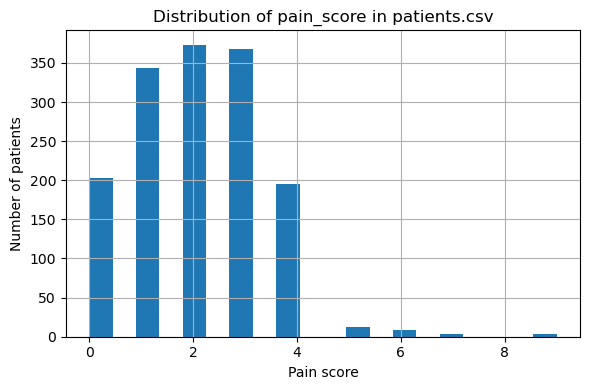

In [6]:
# Distribution of pain_score

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
patients["pain_score"].dropna().hist(bins=20)
plt.xlabel("Pain score")
plt.ylabel("Number of patients")
plt.title("Distribution of pain_score in patients.csv")
plt.tight_layout()
plt.show()

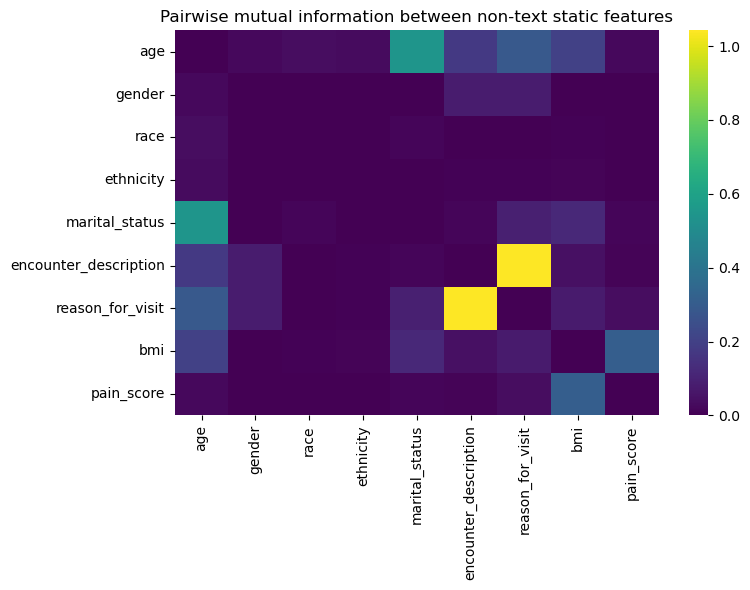

In [8]:
# Pairwise mutual information between non-text static patient features

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# Choose non-clinical-text static features only
mi_features = [
    "age",
    "gender",
    "race",
    "ethnicity",
    "marital_status",
    "encounter_description",
    "reason_for_visit",
    "bmi",
    "pain_score",
]

mi_df = patients[mi_features].copy()

# Basic encoding & numeric imputation
X_enc = mi_df.copy()
feature_types = {}

for col in mi_features:
    if X_enc[col].dtype == "O" or X_enc[col].dtype.name == "category":
        feature_types[col] = "categorical"
        le = LabelEncoder()
        X_enc[col] = le.fit_transform(X_enc[col].astype(str).fillna("<missing>"))
    else:
        feature_types[col] = "numeric"
        X_enc[col] = X_enc[col].astype(float)
        median_val = X_enc[col].median()
        X_enc[col] = X_enc[col].fillna(median_val)

# Compute a symmetric MI matrix: MI(i, j) averaged over both directions
n = len(mi_features)
mi_matrix = np.zeros((n, n))

for i, fi in enumerate(mi_features):
    for j, fj in enumerate(mi_features):
        if i == j:
            mi_matrix[i, j] = 0.0
            continue
        # Mutual information treating fi as target and fj as single-feature input
        xi = X_enc[[fj]].values  # shape (n_samples, 1)
        yi = X_enc[fi].values
        # For regression-style MI, both sides are numeric encodings
        score_ij = mutual_info_regression(xi, yi, random_state=0)[0]

        xj = X_enc[[fi]].values
        yj = X_enc[fj].values
        score_ji = mutual_info_regression(xj, yj, random_state=0)[0]

        mi_matrix[i, j] = (score_ij + score_ji) / 2.0

mi_df_matrix = pd.DataFrame(mi_matrix, index=mi_features, columns=mi_features)

plt.figure(figsize=(8, 6))
sns.heatmap(mi_df_matrix, annot=False, cmap="viridis")
plt.title("Pairwise mutual information between non-text static features")
plt.tight_layout()
plt.show()

The mutual information views above characterize how the static variables relate to one another.

In particular:

- Demographics, encounter descriptors, and simple clinical measures like BMI and pain score show **non-trivial dependence structure**, indicating shared signal and potential redundancy.
- Understanding these relationships helps decide which static fields to keep as separate inputs, which might be safely combined, and where regularization or dimensionality reduction could be helpful.
- Together with the missingness/cardinality views, this guided our choice of a compact static feature set that complements the high-dimensional dynamic vitals.

## 3. Clinical text features

Several static fields contain rich clinical text rather than simple scalar or low-cardinality categorical values:

- `previous_medical_history`
- `current_medications`
- `previous_medications`
- `known_allergies`

These fields typically encode **lists of concepts separated by semicolons (`;`)**, which is important when designing preprocessing and feature extraction steps.

In [9]:
# Inspect sample entries from clinical text fields

text_cols = [
    "previous_medical_history",
    "current_medications",
    "previous_medications",
    "known_allergies",
]

for col in text_cols:
    print(f"\n=== {col} (sample entries) ===")
    sample = patients[col].dropna().head(5)
    for i, entry in enumerate(sample, start=1):
        print(f"{i}. {entry}")

# Simple illustration of splitting on semicolons
example_col = "current_medications"
example_entry = patients[example_col].dropna().iloc[0]
print(f"\nExample raw '{example_col}' entry:\n", example_entry)
print("\nSplit into individual concepts:")
for item in example_entry.split(";"):
    print("-", item.strip())


=== previous_medical_history (sample entries) ===
1. Received higher education (finding); Lack of access to transportation (finding); Transport problem (finding)
2. Risk activity involvement (finding); Serving in military service (finding); Housing unsatisfactory (finding); Educated to high school level (finding); Major depressive disorder (disorder); Body mass index 30+ - obesity (finding); Prediabetes (finding); Victim of intimate partner abuse (finding); Social isolation (finding); Anemia (disorder); Limited social contact (finding); Medication review due (situation); Full-time employment (finding); Gingival disease (disorder); Primary dental caries (disorder); Viral sinusitis (disorder); Gingivitis (disorder); Infection of tooth (disorder); Stress (finding); Leaking dental filling (finding); Reports of violence in the environment (finding); Part-time employment (finding)
3. Medication review due (situation); Acute viral pharyngitis (disorder); Injury of neck (disorder); Whiplash i

## 4. Summary and modeling implications

From this exploratory analysis we draw several conclusions that shape the final model design:

- **Sequence labeling requirement**: The target is defined at the timestamp level (normal / warning / crisis / death), so we need a model that naturally supports **sequence labeling** over fixed-length encounter trajectories.
- **Handling missingness in vitals**: A meaningful fraction of timestamps have missing dynamic features, motivating **systematic imputation** (e.g., interpolation + forward/backward fill) and, where helpful, **explicit missingness masks**.
- **Role of static features**: Static patient descriptors (demographics, encounter metadata, and simple clinical scores) help **cluster patients into different baseline risk profiles**, making it easier for the model to distinguish benign from pathologic vital sign patterns.
- **High-dimensional feature space**: Between multi-channel time-series inputs and high-cardinality clinical text fields, the feature space is high-dimensional. The final architecture therefore needs to handle **high-dimensional inputs** efficiently (both numerically and through appropriate embeddings/encoders for text-like features).

In [10]:
# Quick sanity check: inspect a few rows
patients.head()

,encounter_id,patient_name,age,date_of_birth,gender,race,ethnicity,marital_status,encounter_class,encounter_description,reason_for_visit,previous_medical_history,current_medications,previous_medications,known_allergies,bmi,pain_score
0,b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0,Howard613 Altenwerth646,42,1982-06-10,M,white,nonhispanic,M,emergency,Emergency room admission (procedure),Injury of knee (disorder),Received higher education (finding); Lack of a...,NaN,NaN,NaN,NaN,NaN
1,2657f3db-980c-1bd9-4c19-291544fc3046_1,Bonny428 Cummerata161,60,1964-01-26,F,white,nonhispanic,S,emergency,Emergency room admission (procedure),Laceration - injury (disorder),Risk activity involvement (finding); Serving i...,FLUoxetine 20 MG Oral Capsule; Hydrocortisone ...,sodium fluoride 0.0272 MG/MG Oral Gel,Allergy to substance (finding); Animal dander ...,27.4,1.0
2,0e6b28fb-7cf6-36ab-bb84-a4fdf88ecb50_2,Toby274 Hyatt152,11,2013-06-13,F,white,hispanic,NaN,emergency,Emergency room admission (procedure),Burn injury (morphologic abnormality),NaN,NaN,NaN,NaN,NaN,NaN
3,79bfd6ff-1fb1-c23a-068a-6b9108cc6fa1_3,Rhett759 Bernhard322,29,1995-01-24,M,white,nonhispanic,M,emergency,Emergency treatment (procedure),Impacted molars (disorder),NaN,NaN,NaN,NaN,NaN,NaN
4,7a0ccfea-7f8a-fc6e-35fa-3775b13950da_4,Lucia634 Tromp100,9,2015-10-17,F,white,nonhispanic,NaN,emergency,Emergency room admission (procedure),Sprain (morphologic abnormality),Medication review due (situation); Acute viral...,NaN,Acetaminophen 160 MG Chewable Tablet; Penicill...,NaN,15.6,2.0


In [11]:
# Inspect a small sample of current medications to understand formatting
sample_history = patients["current_medications"].dropna().head(10)

for i, entry in enumerate(sample_history, start=1):
    print(f"{i}. {entry}")

1. FLUoxetine 20 MG Oral Capsule; Hydrocortisone 10 MG/ML Topical Cream; Terfenadine 60 MG Oral Tablet; NDA020800 0.3 ML Epinephrine 1 MG/ML Auto-Injector; ferrous sulfate 325 MG Oral Tablet
2. Simvastatin 10 MG Oral Tablet; 24 HR metoprolol succinate 100 MG Extended Release Oral Tablet; Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray; insulin isophane  human 70 UNT/ML / insulin  regular  human 30 UNT/ML Injectable Suspension [Humulin]; Hydrochlorothiazide 25 MG Oral Tablet; lisinopril 10 MG Oral Tablet; Alendronic acid 10 MG Oral Tablet
3. Jolivette 28 Day Pack
4. Vitamin B12 5 MG/ML Injectable Solution
5. Vitamin B12 5 MG/ML Injectable Solution; Clopidogrel 75 MG Oral Tablet; Simvastatin 20 MG Oral Tablet; 24 HR metoprolol succinate 100 MG Extended Release Oral Tablet; Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray; carvedilol 25 MG Oral Tablet; Furosemide 40 MG Oral Tablet; lisinopril 20 MG Oral Tablet
6. Naproxen sodium 220 MG Oral Tablet; Clopidogrel 75 MG Oral Tablet; Simvastatin 20 MG Oral

In [12]:
# Explore medication name variants and normalize dosage-specific strings

import re
from collections import defaultdict

# Step 1: get all non-NaN entries
all_medications = patients["current_medications"].dropna()

# Step 2: split and strip
split_medications = [item.strip() for entry in all_medications for item in entry.split(";")]

# Step 3: get unique medications and basic stats
unique_medications = set(split_medications)
num_categories = len(unique_medications)

print(f"Number of unique medication categories: {num_categories}")
print("Some sample categories:", list(unique_medications)[:20])

# Step 4: define a function to remove numbers and units

def normalize_medication(name: str) -> str:
    """Remove dosage, units, and numbers from a medication name.

    This keeps the main drug name and form while stripping details like
    strength, volume, and delivery specifics, to better understand
    how many conceptual medications exist beyond dosage variants.
    """
    # remove numbers and common unit patterns (e.g., 20 MG, 0.4 MG/ACTUAT)
    name = re.sub(
        r"\b\d+(\.\d+)?\s*(MG|ML|UNT|MCG|G|MG/ML|MG/ACTUAT|MG/HR)?\b",
        "",
        name,
        flags=re.IGNORECASE,
    )
    # remove brackets and slashes
    name = re.sub(r"[\[\]/]", " ", name)
    # collapse extra whitespace
    name = re.sub(r"\s+", " ", name)
    return name.strip().lower()

# Step 5: group medications by normalized name

groups: dict[str, list[str]] = defaultdict(list)
for med in split_medications:
    norm = normalize_medication(med)
    groups[norm].append(med)

# Step 6: filter groups that actually have more than one variant (different dosages)

dosage_variants = {k: v for k, v in groups.items() if len(v) > 1}

print(f"Number of medication groups with dosage variants: {len(dosage_variants)}\n")

max_groups_to_show = 25
max_variants_to_show = 10

for i, (norm_name, variants) in enumerate(dosage_variants.items(), start=1):
    if i > max_groups_to_show:
        print(f"... (truncated; showing first {max_groups_to_show} groups)")
        break

    unique_variants = sorted(set(variants))
    print(f"{i}. Normalized name: {norm_name}")
    print("   Variants (unique, up to 10 shown):")
    for v in unique_variants[:max_variants_to_show]:
        print(f"     - {v}")
    if len(unique_variants) > max_variants_to_show:
        print(f"     ... ({len(unique_variants) - max_variants_to_show} more variants)")
    print()

Number of unique medication categories: 160
Some sample categories: ['24 HR metoprolol succinate 25 MG Extended Release Oral Tablet', 'insulin isophane  human 70 UNT/ML / insulin  regular  human 30 UNT/ML Injectable Suspension [Humulin]', '1 ML medroxyprogesterone acetate 150 MG/ML Injection', '12 HR Hydrocodone Bitartrate 10 MG Extended Release Oral Capsule', '24 HR propranolol hydrochloride 120 MG Extended Release Oral Capsule', 'cetirizine hydrochloride 10 MG Oral Tablet', 'Diazepam 5 MG Oral Tablet', 'Acetaminophen 300 MG / HYDROcodone Bitartrate 5 MG Oral Tablet', 'Acetaminophen 325 MG Oral Tablet', 'verapamil hydrochloride 80 MG Oral Tablet', 'Etonogestrel 68 MG Drug Implant', 'sulfamethoxazole 800 MG / trimethoprim 160 MG Oral Tablet', 'Digoxin 0.125 MG Oral Tablet', 'hydrochlorothiazide 25 MG / losartan potassium 100 MG Oral Tablet', 'Camila 28 Day Pack', 'Levothyroxine Sodium 0.075 MG Oral Tablet', 'Kyleena 19.5 MG Intrauterine System', 'doxycycline hyclate 100 MG', 'Abuse-Det